# Set ROIs

This notebook allows you to make ROIs for a video without going through the entire pipeline. The example frame used as the image to set the ROIs is fetched using OpenCV's video reader.\
The functionality of this notebook is technically subsumed by the basic pipeline notebook.

**If your data is local**: Just specify the path to the video you want to draw ROIs on.

**If your data is on a server**: OpenCV's video reader allows for you to read just a single frame from a video file without transferring the entire thing IF the server directory is mounted. So we recommend mounting the server directory if possible to avoid transferring the entire file. This can be done with:
- Windows: https://support.microsoft.com/en-us/windows/map-a-network-drive-in-windows-29ce55d1-34e3-a7e2-4801-131475f9557d
- OSX: https://www.google.com/search?q=mount+network+drive+osx
- Linux: Use RClone CLI: `rclone mount remote:path/to/files /path/to/local/mount`
    - Example: `rclone mount transfer:/n/files/Neurobio/MICROSCOPE/ /mnt/MICROSCOPE/`
    

In [1]:
# ALWAYS RUN THIS CELL
# widen jupyter notebook window
from IPython.display import display, HTML
display(HTML("<style>.container {width:95% !important; }</style>"))

%load_ext autoreload
%autoreload 2
import face_rhythm as fr
import face_rhythm.alignment

from pprint import pprint
from pathlib import Path
import copy
import getpass

import cv2

import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
import natsort

try:
    import bnpm
except:
    pass

fr.util.system_info(verbose=True);

2025-04-04 18:56:33.999 python[97800:4083318] +[IMKClient subclass]: chose IMKClient_Modern
2025-04-04 18:56:33.999 python[97800:4083318] +[IMKInputSession subclass]: chose IMKInputSession_Modern
2025-04-04 18:56:36.105 python[97800:4083318] _TIPropertyValueIsValid called with 16 on nil context!
2025-04-04 18:56:36.105 python[97800:4083318] imkxpc_getApplicationProperty:reply: called with incorrect property value 16, bailing.
2025-04-04 18:56:36.105 python[97800:4083318] Text input context does not respond to _valueForTIProperty:
INFO:numexpr.utils:NumExpr defaulting to 8 threads.


== Operating System ==: uname_result(system='Darwin', node='Richards-MacBook-Air-2.local', release='24.3.0', version='Darwin Kernel Version 24.3.0: Thu Jan  2 20:23:36 PST 2025; root:xnu-11215.81.4~3/RELEASE_ARM64_T8112', machine='arm64')
== CPU Info ==: Error: Failed to get
== RAM ==: svmem(total=25769803776, available=17990696960, percent=30.2, used=5298749440, free=14347665408, active=2481586176, inactive=3467591680, wired=2817163264)
== GPU Info ==: {}
== Conda Environment ==: fr
== Python Version ==: 3.11.11
== GCC Version ==: (clang-1600.0.26.6)
== PyTorch Version ==: 2.6.0
== CUDA is not available ==
== face_rhythm Version ==: <module 'face_rhythm' from '/Users/richardhakim/Documents/github_repos/face-rhythm/face_rhythm/__init__.py'>
== face_rhythm date installed ==: Tue Mar 25 21:06:15 2025


/Users/richardhakim/Documents/github_repos/face-rhythm/face_rhythm/util.py:978: UserWarning: RH WARNING: unable to get cpu info. Got error: [Errno 13] Permission denied
  warnings.warn(f'RH WARNING: unable to get cpu info. Got error: {e}')


## Set paths

In [2]:
use_remote = False  ## set to True if running on remote machine. Will use SFTP to find files and load frames

In [3]:
directory_videos  = '/Users/richardhakim/Documents/data/facerhythm_stroke_biomarker_exp/camera/20250303/PS46'
filename_strMatch = 'video1_2025-03-03T15_42_05'  ## You can use regular expressions to search and match more complex strings

In [4]:
if use_remote:
    import bnpm
    import getpass
    username=input("Enter your username: ")
    password=getpass.getpass(prompt="Enter your password: ")

    use_localSshKey = False
    path_sshKey = '/home/rich/.ssh/id_rsa' if use_localSshKey else None
    
    ssh_t = bnpm.server.ssh_interface(
        nbytes_toReceive=20000,
        recv_timeout=1,
        verbose=True,
    )
    ssh_t.o2_connect(
        hostname='transfer.rc.hms.harvard.edu',
        username=username,
        password=password if (use_localSshKey==False) else None,
        key_filename=path_sshKey,
        look_for_keys=False,
        passcode_method=1,
        verbose=0,
        skip_passcode=False,    
    )
    # ssh_t.fasrc_connect(
    #     hostname='login.rc.fas.harvard.edu',
    #     username=input('Username: '),
    #     password=getpass.getpass(prompt='Password: ') if (use_localSshKey==False) else None,
    #     verbose=0,
    # )
    sftp_t = bnpm.server.sftp_interface(ssh_client=ssh_t.client)

In [5]:
if use_remote:
    paths_videos = sftp_t.search_recursive(
        dir_outer=directory_videos, 
        reMatch=filename_strMatch, 
#         reMatch_in_path='PS46',
        depth=5,
        find_files=True,
        find_folders=True,
        natsorted=True,
        verbose=True
    )
else:
    paths_videos = fr.helpers.find_paths(
        dir_outer=directory_videos,
        reMatch=filename_strMatch,  ## string to use to search for files in directory. Uses regular expressions!alg_ns=
        # reMatch_in_path='PS47',
        depth=5,  ## how many folders deep to search
        verbose=True,
    )

display(paths_videos)

Found file: /Users/richardhakim/Documents/data/facerhythm_stroke_biomarker_exp/camera/20250303/PS46/video1_2025-03-03T15_42_05.avi


['/Users/richardhakim/Documents/data/facerhythm_stroke_biomarker_exp/camera/20250303/PS46/video1_2025-03-03T15_42_05.avi']

In [6]:
names_sessions = natsort.natsorted([Path(p).parts[-3].replace('-', '') for p in paths_videos])
# names_sessions = natsort.natsorted([bnpm.path_helpers.find_date_in_path(p).replace('-', '') for p in paths_videos])
names_sessions

['20250303']

## Fetch image

In [7]:
idx_template = 0

In [8]:
path_vid_template = paths_videos[idx_template]
path_vid_template

'/Users/richardhakim/Documents/data/facerhythm_stroke_biomarker_exp/camera/20250303/PS46/video1_2025-03-03T15_42_05.avi'

#### Using a remote server
- (if your videos are on the local computer, then skip past this step)
- Make sure ffmpeg is installed if you want to import first frames from a remote server. It is not necessary otherwise

In [9]:
if use_remote:
    # Replace with your actual connection details and remote video path.
    extractor = fr.alignment.SFTPVideoFrameExtractor(
        host="transfer.rc.hms.harvard.edu",
        username=username,
        password=password,
        port=22,  # or your specific port
    )

In [21]:
time_start = 0  # Start time in seconds
duration = 20  # Duration to capture in seconds

if use_remote:
    # Specify the path to the remote video file.
    im_test = np.array(extractor.extract_frames(path_vid_template, time_start=time_start, duration=duration), dtype=np.float32).mean(-1)
else:
    im_test = fr.alignment.get_frames(path_vid_template, time_start, time_start + duration)

Found fps: 250.0
sample_start: 0.0, sample_end: 5000.0
num_frames: 5000


100%|███████████████████████████████████████████████████████████████| 5000/5000 [00:18<00:00, 270.44it/s]


In [22]:
# bnpm.misc.estimate_array_size(im_test)

In [23]:
pipeline = fr.alignment.Image_preparation_pipeline(
    ds_factor=20,
    ptile_specVar_keep=10,
    ptile_intensity_keep=100,
    params_vqt={
        "Fs_sample": 250,
        "Q_lowF": 3.5,
        "Q_highF": 20,
        "F_min": 0.5,
        "F_max": 60,
        "n_freq_bins": 50,
        "window_type": 'hann',
        "downsample_factor": 10,
        "fft_conv": True,
        "plot_pref": False,
    },
    clip_limit=2.0,
    grid_size=60,
    verbose=True,
)

downsampling...
Images shape: (5000, 600, 800)
Images downsampled shape: (5000, 30, 40)
computing spectrograms...
applying CLAHE...


100%|██████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 64.49it/s]


(600, 800)

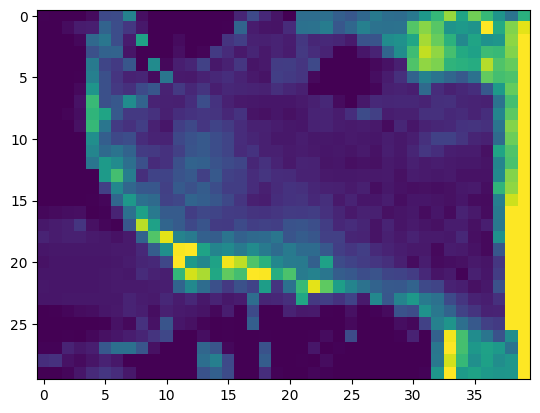

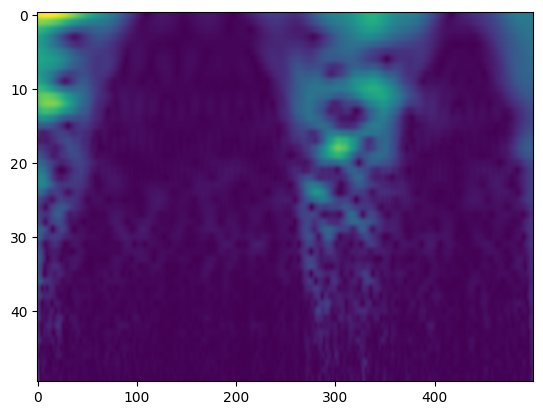

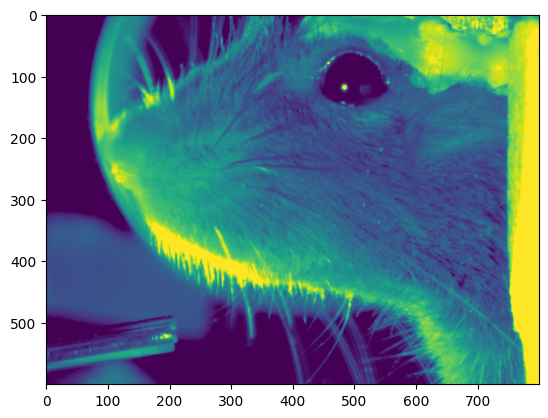

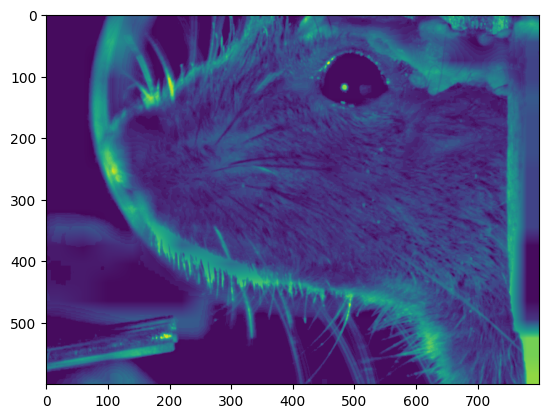

In [17]:
im_aug = pipeline.apply_pipeline(torch.as_tensor(im_test, dtype=torch.float32).mean(-1).numpy())
im_aug.shape

# Define ROIs

Either select new ROIs (`select_mode='gui'`), or import existing ROIs (`path_file=path_to_ROIs.h5_file`).\
Typically, you should make 1 or 2 ROIs. One for defining where the face points should be and one for cropping the frame.

In [18]:
# im_aug = np.load(r'/Users/richardhakim/Documents/data/facerhythm_stroke_biomarker_exp/analysis/face_rhythm/aligned_dots/cam1/im_template.npy')

FR: Initializing GUI...


<IPython.core.display.Javascript object>


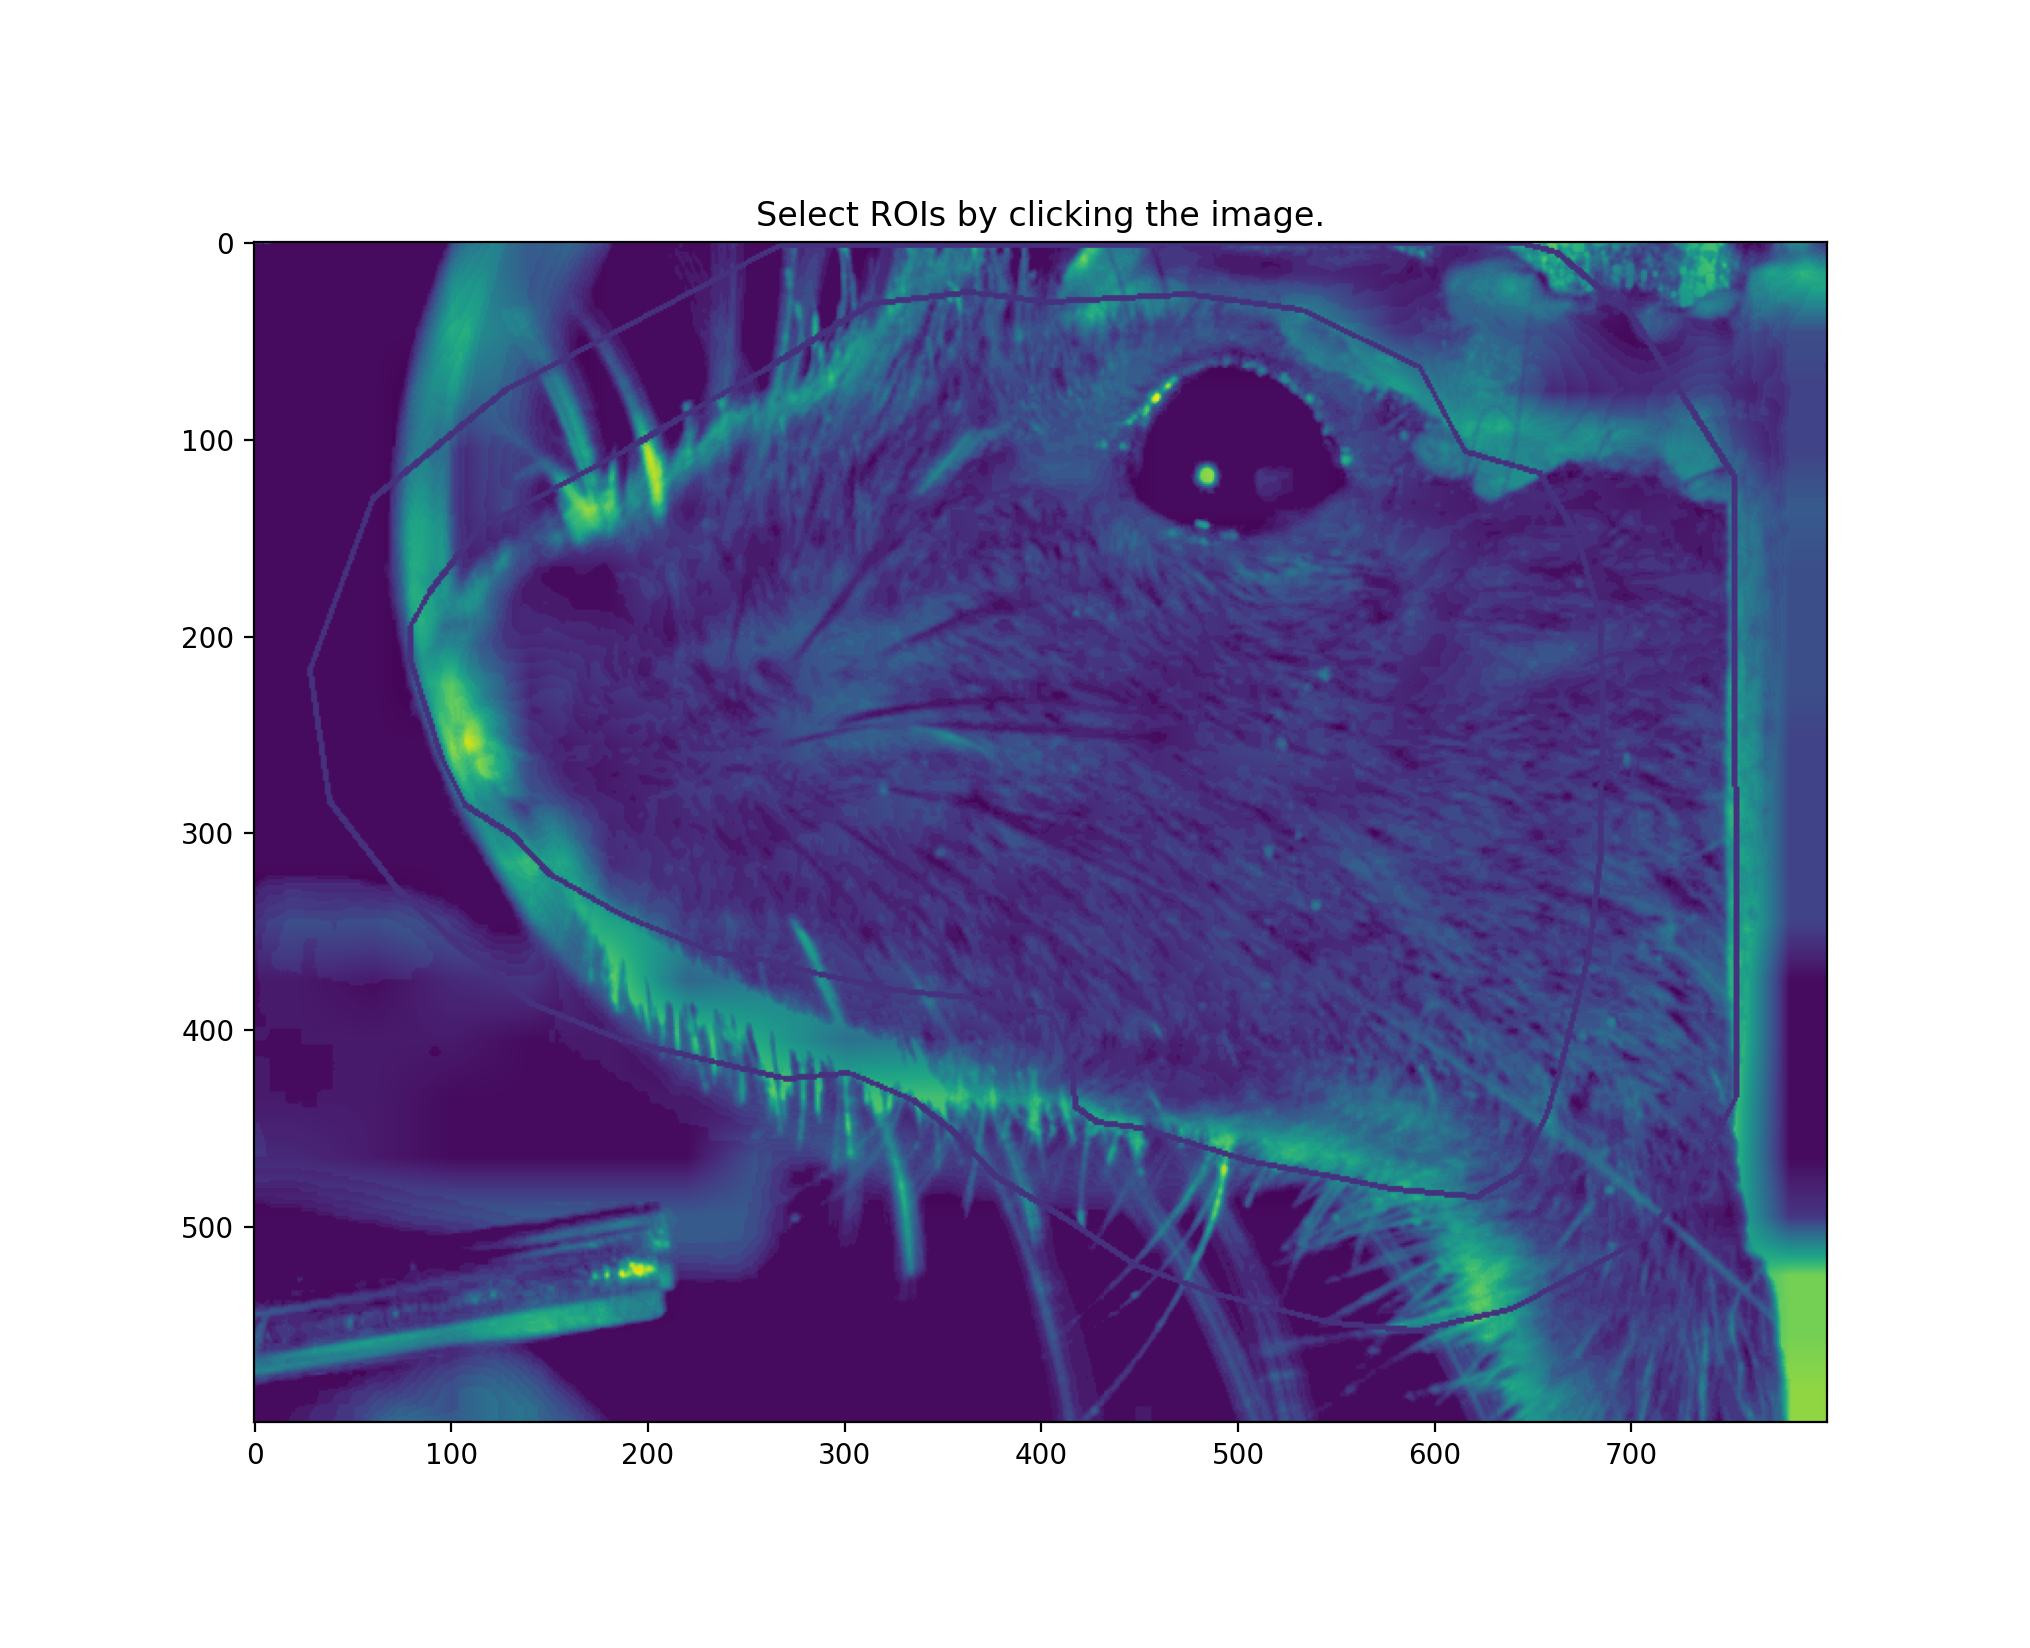

Button(description='Confirm ROI', style=ButtonStyle())

Button(description='New ROI', style=ButtonStyle())

mask_frames computed


In [8]:
%matplotlib widget
rois = fr.rois.ROIs(
    select_mode='gui',
    exampleImage=im_aug,
    # select_mode='file',
    # path_file=r'/Users/richardhakim/Documents/data/test_fr_run_20250304_mousePS46_date20250303_cam1/analysis_files/ROIs.h5',
    verbose=2
)

Save the `ROIs` object in the 'analysis_files' project folder

FR: Making points to track
FR: 1861 points total


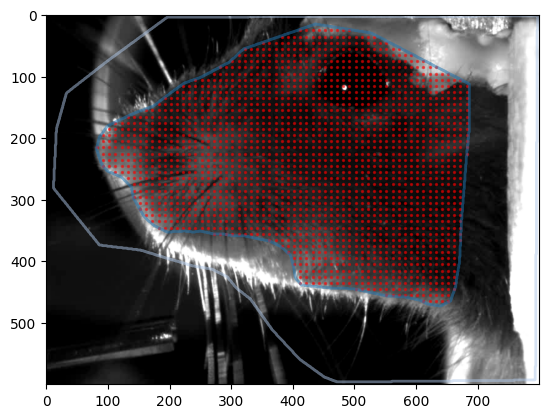

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [26]:
rois.make_points(rois[0], point_spacing=10)
rois.plot_rois()

FR: Making points to track
FR: 1966 points total


<IPython.core.display.Javascript object>


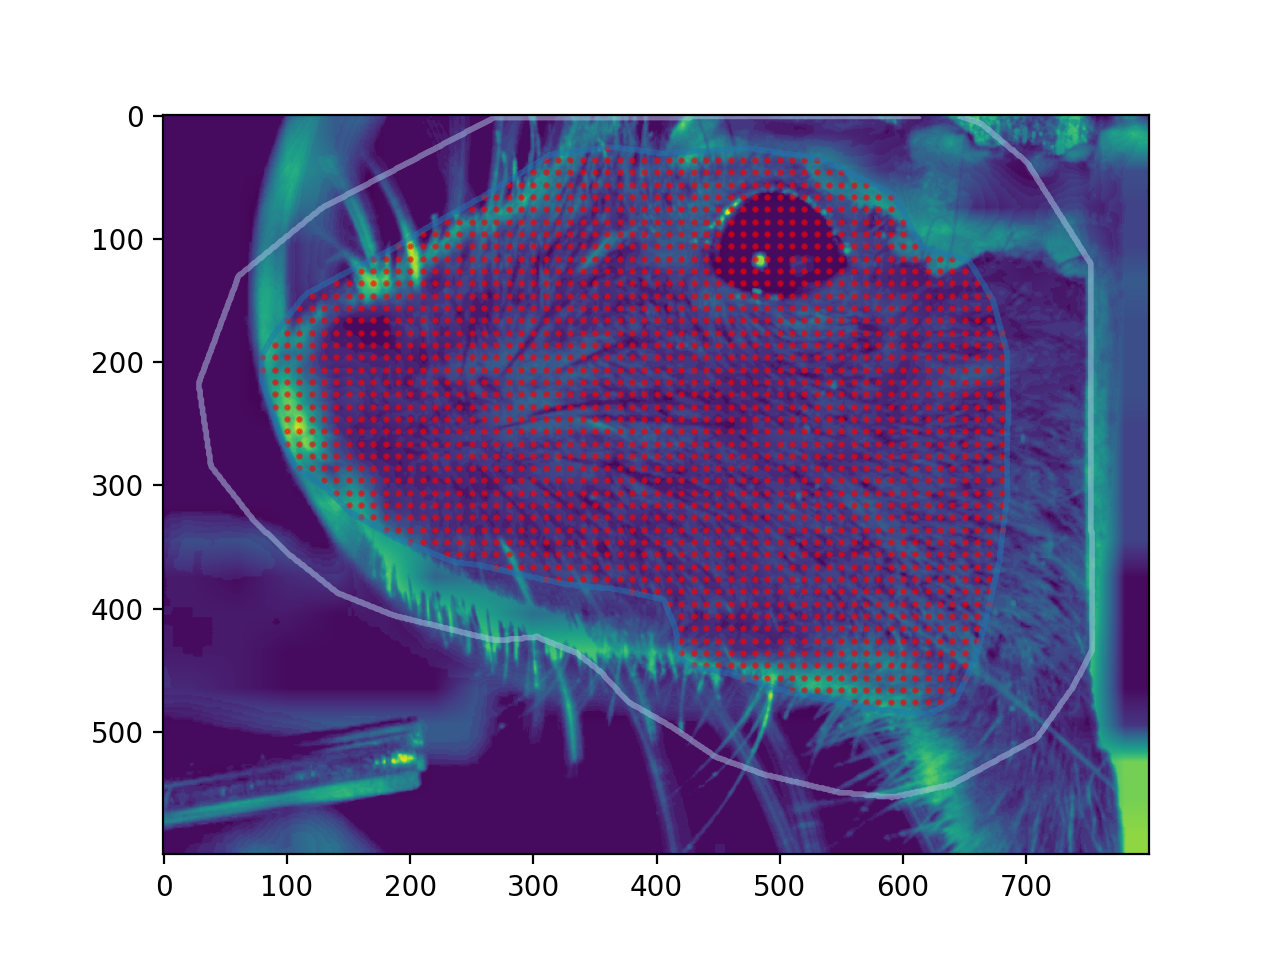

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [9]:
rois.make_points(rois[0], point_spacing=10)
rois.plot_rois()

In [5]:
directory_save = r'/Users/richardhakim/Documents/data/facerhythm_stroke_biomarker_exp/analysis/face_rhythm/aligned_dots/cam1/template/ROIs.h5'

In [6]:
path_save = str(Path(directory_save) / 'ROIs.h5')
rois.save_run_data(path_run_data=path_save, overwrite=True, verbose=1)

# Optional: Multisession alignment

The below code shows how to align the points from one 'template' session onto multiple other 'new' sessions.\
Steps:
1. Get example images from each session: `images`
2. Optionally adjust the local contrast of each example image to make: `images_toUse`
3. Instantiate the `ROI_Aligner` class and choose which OpenCV optical flow method to use: `aligner`
4. Perform non-rigid registration to warp the 'template' ROIs and points onto the example images from each session: `aligner.align_and_make_ROIs`
5. Retrieve the newly made `ROIs` class objects: `rois_objs_new = aligner.ROIs_objects_new`
6. Save the new `ROIs` class objects: `rois_objs_new[x].save_run_data()`
7. Visualize the results!

1. Get example images

In [26]:
import warnings
from tqdm import tqdm

def get_first_frames(paths, max_attempts=5, verbose=True):
    if isinstance(paths, list) == False:
        paths = [paths]

    def get_first_frame(path, attempt=0):
        frame = cv2.VideoCapture(path).read()[1]
        if frame is None:
            print(f"Received `None` for path: {path}. Attempting again; attempt number: {attempt}")
            if attempt + 1 > max_attempts:
                warnings.warn(f"Failed to get first frame for path:{path}")
                return None
            frame = get_first_frame(path, attempt=attempt+1)
        return frame

    flag_singleOutput = len(paths) == 1
    out = [get_first_frame(path) for path in tqdm(paths, disable=flag_singleOutput)]
    out = out[0] if flag_singleOutput else out
    
    return out

In [19]:
paths_videos

['/Users/richardhakim/Documents/data/facerhythm_stroke_biomarker_exp/camera/20250303/PS46/video1_2025-03-03T15_42_05.avi']




  0%|                                                                              | 0/1 [00:00<?, ?it/s]

Found fps: 250.0
sample_start: 0.0, sample_end: 5000.0
num_frames: 5000






  0%|                                                                           | 0/5000 [00:00<?, ?it/s]



  1%|▍                                                                | 32/5000 [00:00<00:15, 311.22it/s]



  1%|▊                                                                | 64/5000 [00:00<00:18, 263.69it/s]



  2%|█▏                                                               | 91/5000 [00:00<00:18, 258.40it/s]



  2%|█▌                                                              | 118/5000 [00:00<00:19, 254.35it/s]



  3%|█▊                                                              | 144/5000 [00:00<00:19, 252.28it/s]



  3%|██▏                                                             | 170/5000 [00:00<00:19, 250.18it/s]



  4%|██▌                                                             | 196/5000 [00:00<00:19, 247.69it/s]



  4%|██▊                                                             | 221/5000 [00:00<00:19, 246.23it/s]



  5%|███▏      

 38%|███████████████████████▉                                       | 1904/5000 [00:06<00:10, 286.69it/s]



 39%|████████████████████████▎                                      | 1933/5000 [00:06<00:10, 286.86it/s]



 39%|████████████████████████▋                                      | 1962/5000 [00:07<00:10, 286.59it/s]



 40%|█████████████████████████                                      | 1991/5000 [00:07<00:10, 287.49it/s]



 40%|█████████████████████████▍                                     | 2020/5000 [00:07<00:10, 285.41it/s]



 41%|█████████████████████████▊                                     | 2050/5000 [00:07<00:10, 287.34it/s]



 42%|██████████████████████████▏                                    | 2079/5000 [00:07<00:10, 286.58it/s]



 42%|██████████████████████████▌                                    | 2109/5000 [00:07<00:10, 288.80it/s]



 43%|██████████████████████████▉                                    | 2138/5000 [00:07<00:09, 288.27it/s]



 43%|██████████████

 75%|███████████████████████████████████████████████▎               | 3754/5000 [00:13<00:04, 277.82it/s]



 76%|███████████████████████████████████████████████▋               | 3782/5000 [00:13<00:04, 277.94it/s]



 76%|████████████████████████████████████████████████               | 3811/5000 [00:14<00:04, 278.88it/s]



 77%|████████████████████████████████████████████████▍              | 3840/5000 [00:14<00:04, 279.69it/s]



 77%|████████████████████████████████████████████████▋              | 3868/5000 [00:14<00:04, 276.80it/s]



 78%|█████████████████████████████████████████████████              | 3897/5000 [00:14<00:03, 278.94it/s]



 79%|█████████████████████████████████████████████████▍             | 3926/5000 [00:14<00:03, 279.64it/s]



 79%|█████████████████████████████████████████████████▊             | 3955/5000 [00:14<00:03, 281.11it/s]



 80%|██████████████████████████████████████████████████▏            | 3984/5000 [00:14<00:03, 282.36it/s]



 80%|██████████████

downsampling...
Images shape: (5000, 600, 800)
Images downsampled shape: (5000, 30, 40)
computing spectrograms...


  0%|                                                                              | 0/1 [01:37<?, ?it/s]


applying CLAHE...



100%|██████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 48.13it/s]



100%|██████████████████████████████████████████████████████████████████████| 1/1 [00:58<00:00, 58.16s/it]


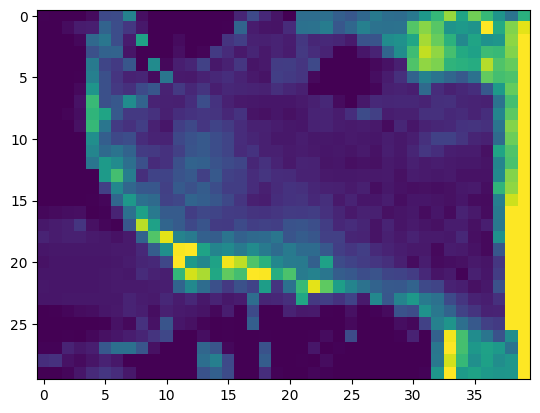

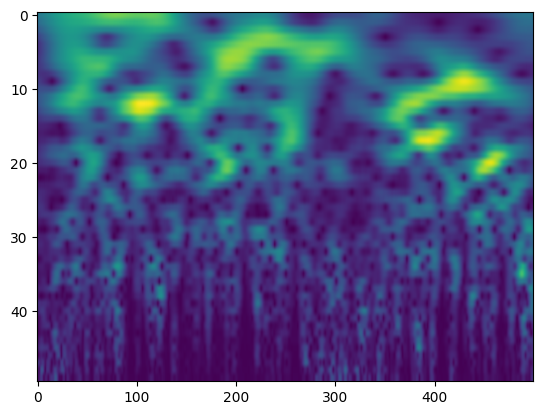

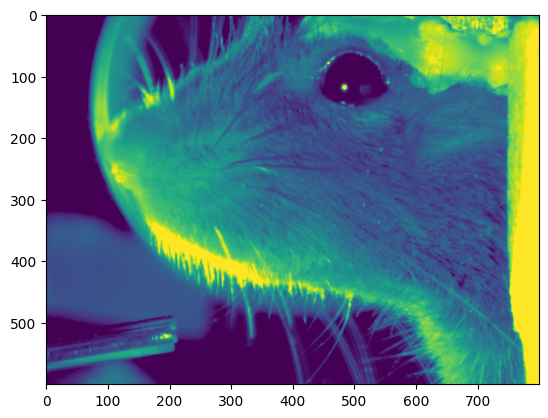

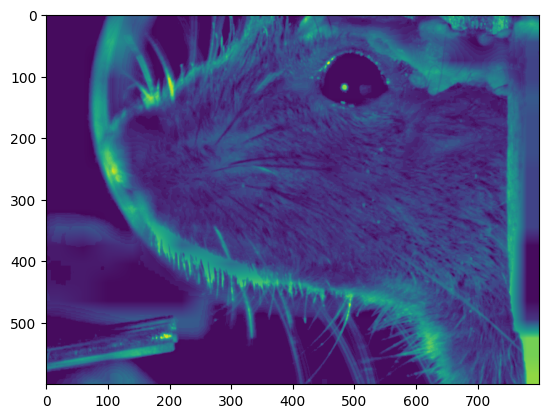

In [28]:
%matplotlib inline
if use_remote:
    images = {path: pipeline.apply_pipeline(torch.as_tensor(extractor.extract_frames(path, time_start=0, duration=30), dtype=torch.float32).mean(-1).numpy()) for path in tqdm(paths_videos)}
else:
    images = {path: pipeline.apply_pipeline(torch.as_tensor(fr.alignment.get_frames(path, time_start=0, time_end=20), dtype=torch.float32).mean(-1).numpy()) for path in tqdm(paths_videos)}

2. Optionally adjust local contrast

3. to 5. Register ROIs from template to new session images, then make new `ROIs` objects

In [25]:
ims_aug = list(images.values())

In [26]:
# im_aug_template = ims_aug[idx_template]
im_aug_template = np.load("/Users/richardhakim/Documents/data/aligned_dots/cam1/im_template.npy")


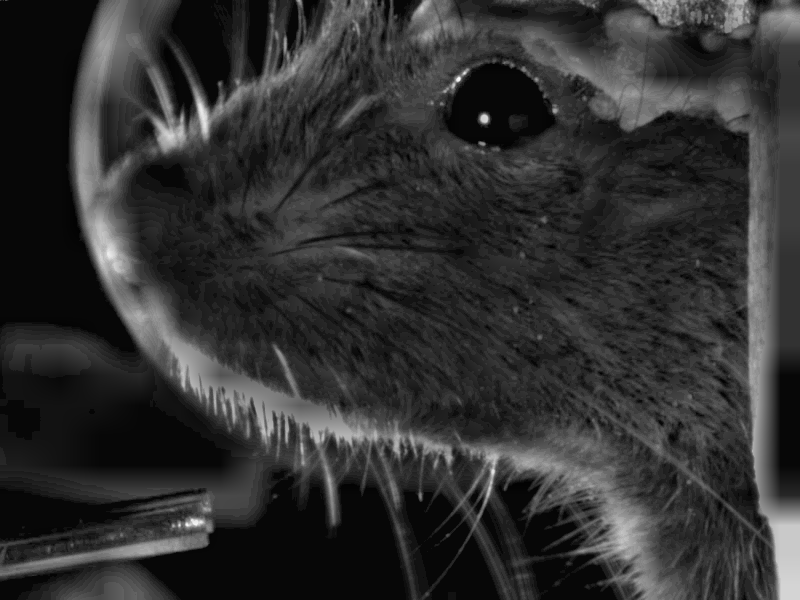

In [27]:
fr.visualization.display_toggle_image_stack([im_aug_template] + ims_aug)

In [28]:
aligner = fr.rois.Image_Aligner(verbose=True)

aligner.fit_geometric(
    template=im_aug_template,  ## template image
    ims_moving=ims_aug,  ## images to align
    template_method='image',  ## 'sequential': align images to neighboring images (good for drifting data). 'image': align to a single image
    mode_transform='euclidean',  ## type of geometric transformation. See openCV's cv2.findTransformECC for details
    mask_borders=(0,150,150,50),  ## number of pixels to mask off the edges (top, bottom, left, right)
    n_iter=50,  ## number of iterations for optimization
    termination_eps=1e-09,  ## convergence tolerance
    gaussFiltSize=41,  ## size of gaussian blurring filter applied to all images
    auto_fix_gaussFilt_step=10,  ## increment in gaussFiltSize after a failed optimization
)

aligner.transform_images_geometric(ims_aug);

im_template_geo = aligner.transform_images(
    ims_moving=[im_aug_template],
    remappingIdx=aligner.remappingIdx_geo,
)[0]

Finding geometric registration warps with mode: euclidean, template_method: image, mask_borders: True


Finding geometric registration warps: 100%|██████████| 1/1 [00:00<00:00,  3.55it/s]

Composing geometric warp matrices...
Applying geometric registration warps to images...


In [29]:
aligner.fit_nonrigid(
    template=im_template_geo,  ## template image
#     template=int(0),  ## specifies which image to use as the template. Either array (image), integer (ims_moving index), or float (ims_moving fractional index)
    ims_moving=aligner.ims_registered_geo,  ## Input images. Typically the geometrically registered images
    remappingIdx_init=aligner.remappingIdx_geo,  ## The remappingIdx between the original images (and ROIs) and ims_moving
    template_method='image',  ## 'sequential': align images to neighboring images. 'image': align to a single image, good if using geometric registration first
    mode_transform='createOptFlow_DeepFlow',  ## algorithm for non-rigid transformation. Either 'createOptFlow_DeepFlow' or 'calcOpticalFlowFarneback'. See openCV docs for each. 
    kwargs_mode_transform=None,  ## kwargs for `mode_transform`
)

aligner.transform_images_nonrigid(list(images.values()));

Finding nonrigid registration warps with mode: createOptFlow_DeepFlow, template_method: image


Finding nonrigid registration warps: 100%|██████████| 1/1 [00:00<00:00,  1.52image/s]

Composing nonrigid warp matrices...
Applying nonrigid registration warps to images...



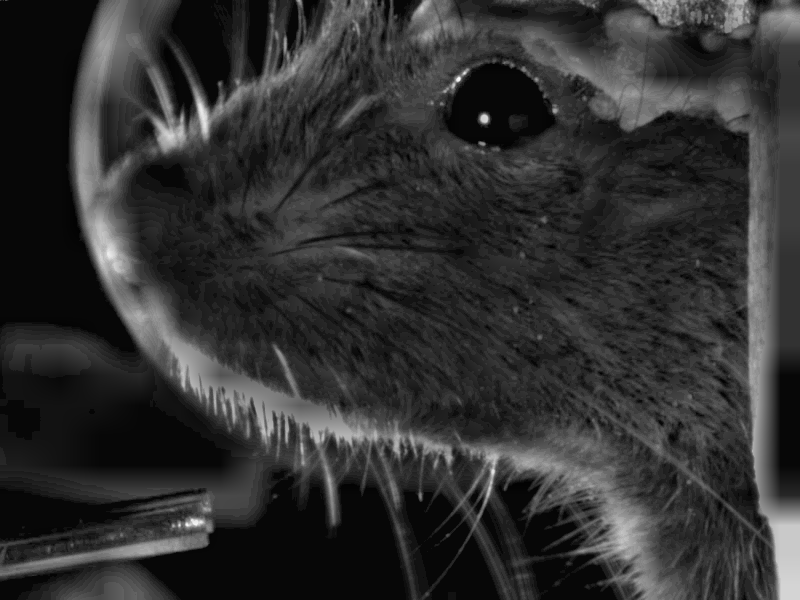


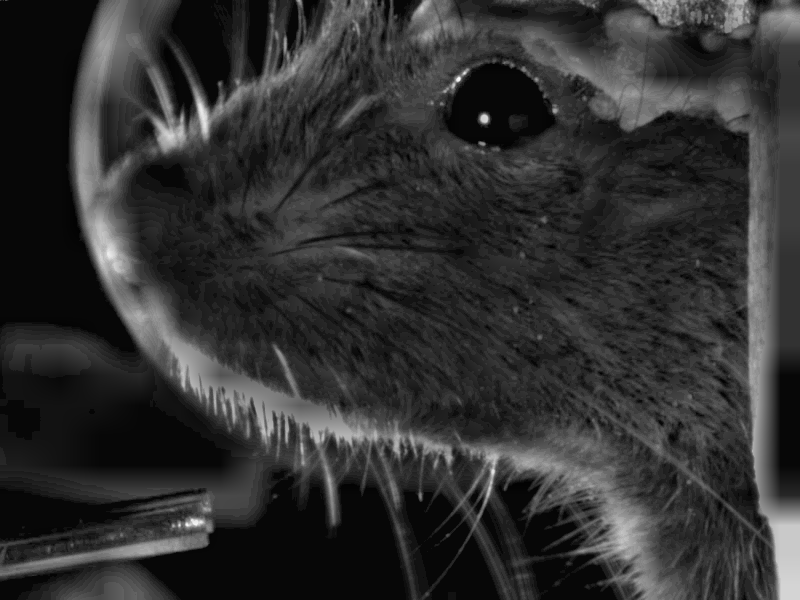

In [41]:
fr.visualization.display_toggle_image_stack([im_aug_template] + aligner.ims_registered_geo)

fr.visualization.display_toggle_image_stack([im_aug_template] + aligner.ims_registered_nonrigid)

In [31]:
remappingIdx = copy.deepcopy(aligner.remappingIdx_geo)

points_roiBorders_transformed = [{key: aligner.transform_points(
    points=points,
    remappingIdx=rmap_idx,
) for key, points in rois.roi_points.items()} for rmap_idx in remappingIdx]

points_forTracking_transformed = [aligner.transform_points(
    points=rois.point_positions,
    remappingIdx=rmap_idx,
) for rmap_idx in remappingIdx]

# exampleImages = list(images.values())
exampleImages = [np.tile((e * (0.15)).astype(np.uint8)[..., None], (1, 1, 3)) for e in images.values()]

In [32]:
rois_objs_new = {name: fr.rois.ROIs(
    select_mode='custom', 
    coords_rois=borderPoints, 
    exampleImage=exampleImage, 
    point_positions=point_positions
) for name, borderPoints, exampleImage, point_positions in tqdm(zip(paths_videos, points_roiBorders_transformed, exampleImages, points_forTracking_transformed))}

1it [00:00,  6.59it/s]


## 6. Save
Save the new `ROIs` objects. These can be used to initialize the `ROIs` objects in each face-rhythm run.

In [35]:
# names_sessions = ['__'.join(Path(name).parts[-6:-4]) for name in rois_objs_new.keys()]

for ii, (name, rois_new) in enumerate(rois_objs_new.items()):
    path_save = str(Path(directory_save) / names_sessions[ii] / f'ROIs.h5')
#     path_save = str(Path(directory_save) / f'ROIs.h5')
    rois_new.save_run_data(
        path_run_data=path_save,
        overwrite=True,
        verbose=1,
    )

FR WARNING: path_run_data file is expected to be named 'ROIs.h5' if it is part of a project. Please make sure this is correct.


## 7. Visualize!


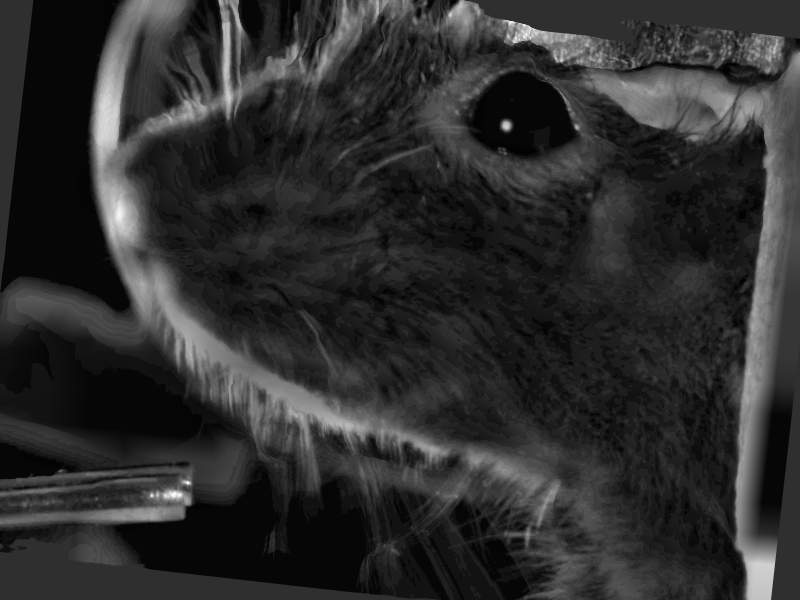

In [36]:
fr.visualization.display_toggle_image_stack(aligner.ims_registered_nonrigid)

In [37]:
## Cast to uint8
movie = [np.tile((im * 0.15).astype(np.uint8)[:,:,None], (1,1,3)) for im in aligner.ims_registered_nonrigid]
## Add text overlay
movie = fr.helpers.add_text_to_images(movie, [[str(n)] for n in np.arange(len(movie))], position=(50,100), font_size=4, line_width=5,)

image_saver = fr.util.Image_Saver(
    dir_save=directory_save,
    overwrite=True,
)

image_saver.save_gif(
    array_images=movie, 
    name_save='mouse_face_matched', 
    frame_rate=10.0, 
    loop=0, 
)

In [38]:
frame_visualizer = fr.visualization.FrameVisualizer(
    display=False,
    frame_height_width=rois_objs_new[list(rois_objs_new.keys())[0]].img_hw,
    point_sizes=3,
    points_colors=(255,0,0),
    alpha=0.5,
)

images_with_warped_points = [frame_visualizer.visualize_image_with_points(
    image=rois.exampleImage,
    points=rois.point_positions,
) for rois in rois_objs_new.values()]


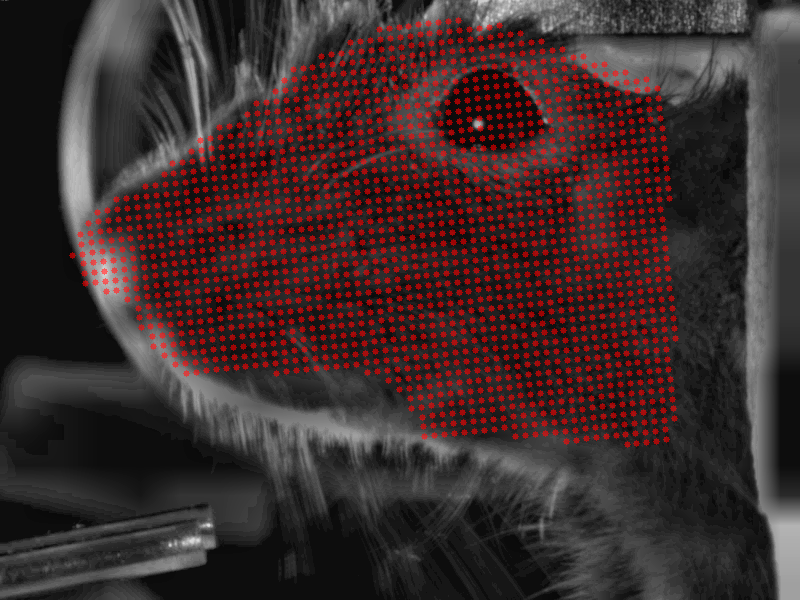

In [39]:
fr.visualization.display_toggle_image_stack(images_with_warped_points)

In [42]:
directory_save

'/Users/richardhakim/Documents/data/aligned_dots/'

In [40]:
## Cast to uint8
movie = [im.astype(np.uint8) for im in images_with_warped_points]
## Add text overlay
movie = fr.helpers.add_text_to_images(movie, [[str(n)] for n in np.arange(len(movie))], position=(50,100), font_size=4, line_width=5,)

image_saver = fr.util.Image_Saver(
    dir_save=directory_save,
    overwrite=True,
)

image_saver.save_gif(
    array_images=movie, 
    name_save='mouse_face_points_matched', 
    frame_rate=3.0, 
    loop=0, 
)